In [1]:
!pip install openpyxl scipy statsmodels seaborn --quiet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    shapiro,
    levene,
    ttest_ind,
    mannwhitneyu,
    chi2_contingency
)

from statsmodels.stats.proportion import  proportions_ztest
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", None)
sns.set(style = "whitegrid")



In [7]:
from google.colab import files
uploaded = files.upload()
df = pd.read_excel("ab_test_dataset.xlsx")
df.head(3)

Saving ab_test_dataset.xlsx to ab_test_dataset (2).xlsx


,user_id,experiment_id,variant,assignment_ts,age,grade_level,region,device_type,network_quality,parent_education,income_band,prior_platform_days,prior_sessions_30d,baseline_math_score,baseline_reading_score,self_efficacy_score,attention_score,learning_style,weak_topic_primary,weak_topic_secondary,study_goal_mins_week,session_count_14d,total_minutes_14d,avg_session_minutes,recommendations_served,recommendations_clicked,recommendations_completed,recommendation_ctr,recommendation_completion_rate,recommendation_relevance_survey_1_5,learning_speed_survey_1_5,ux_satisfaction_1_5,trust_ai_1_5,nps_score,module_completion_rate,post_quiz_score,score_gain_pct,retained_7d,retained_30d,subscription_converted,refund_requested,fairness_flag,latency_ms_avg,app_crash_count,data_quality_score,cheating_risk_score,anomaly_flag,lifetime_value_usd
0,U000001,EXP2026LP01,A,2026-03-01 08:03:00,14,9,North,Android,High,Masters,Mid,198,19,63.9,60.7,2.8,63.1,Mixed,Fractions,Geometry,200,5,76.6,23.0,14,3,4,0.219,0.258,2,2,5,3,19,0.366,66.6,4.25,1,1,1,0,0,161,0,0.998,0.029,0,11.12
1,U000002,EXP2026LP01,B,2026-03-01 08:06:00,14,9,South,Android,Medium,Masters,Mid,115,19,69.7,68.2,4.2,76.4,Kinesthetic,Algebra,Calculus,360,8,150.3,21.3,24,9,7,0.362,0.278,4,3,4,4,64,0.944,83.4,19.64,1,0,0,0,0,250,0,1.000,0.035,0,82.11
2,U000003,EXP2026LP01,A,2026-03-01 08:09:00,11,6,West,Android,High,HighSchool,Low,292,18,66.0,67.0,3.5,44.1,Visual,Fractions,Geometry,360,10,156.1,16.1,14,3,2,0.243,0.177,4,3,4,2,-3,0.504,74.3,12.51,0,1,0,0,0,80,0,1.000,0.050,0,16.07


In [8]:
print("Shape", df.shape)


Shape (2000, 48)


In [9]:
print("Columns", df.columns.tolist())

Columns ['user_id', 'experiment_id', 'variant', 'assignment_ts', 'age', 'grade_level', 'region', 'device_type', 'network_quality', 'parent_education', 'income_band', 'prior_platform_days', 'prior_sessions_30d', 'baseline_math_score', 'baseline_reading_score', 'self_efficacy_score', 'attention_score', 'learning_style', 'weak_topic_primary', 'weak_topic_secondary', 'study_goal_mins_week', 'session_count_14d', 'total_minutes_14d', 'avg_session_minutes', 'recommendations_served', 'recommendations_clicked', 'recommendations_completed', 'recommendation_ctr', 'recommendation_completion_rate', 'recommendation_relevance_survey_1_5', 'learning_speed_survey_1_5', 'ux_satisfaction_1_5', 'trust_ai_1_5', 'nps_score', 'module_completion_rate', 'post_quiz_score', 'score_gain_pct', 'retained_7d', 'retained_30d', 'subscription_converted', 'refund_requested', 'fairness_flag', 'latency_ms_avg', 'app_crash_count', 'data_quality_score', 'cheating_risk_score', 'anomaly_flag', 'lifetime_value_usd']


In [10]:
df = df.drop_duplicates()

In [11]:
df.count()

,0
user_id,2000
experiment_id,2000
variant,2000
assignment_ts,2000
age,2000
grade_level,2000
region,2000
device_type,2000
network_quality,2000
parent_education,2000


In [12]:
missing = df.isnull().sum().sort_values(ascending= False)
display(missing[missing > 0])

for col in df.select_dtypes(include = np.number).columns:
  df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include = "object").columns:
  df[col] = df[col].fillna("Unknown")
print("complete")

,0


complete


In [13]:
possible_variant_cols = [
     "variant",
    "group",
    "test_group",
    "experiment_group",
    "ab_group"
]
variant_col = None
for c in possible_variant_cols:
  if c in df.columns:
    variant_col = c
    break
print("Variant Column", variant_col)
print(df[variant_col].value_counts())

Variant Column variant
variant
B    1009
A     991
Name: count, dtype: int64


,user_id,experiment_id,variant,assignment_ts,age,grade_level,region,device_type,network_quality,parent_education,income_band,prior_platform_days,prior_sessions_30d,baseline_math_score,baseline_reading_score,self_efficacy_score,attention_score,learning_style,weak_topic_primary,weak_topic_secondary,study_goal_mins_week,session_count_14d,total_minutes_14d,avg_session_minutes,recommendations_served,recommendations_clicked,recommendations_completed,recommendation_ctr,recommendation_completion_rate,recommendation_relevance_survey_1_5,learning_speed_survey_1_5,ux_satisfaction_1_5,trust_ai_1_5,nps_score,module_completion_rate,post_quiz_score,score_gain_pct,retained_7d,retained_30d,subscription_converted,refund_requested,fairness_flag,latency_ms_avg,app_crash_count,data_quality_score,cheating_risk_score,anomaly_flag,lifetime_value_usd
count,2000,2000,2000,2000,2000.000000,2000.000000,2000,2000,2000,2000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000,2000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
unique,2000,1,2,NaN,NaN,NaN,4,4,3,3,3,NaN,NaN,NaN,NaN,NaN,NaN,5,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,U001984,EXP2026LP01,B,NaN,NaN,NaN,South,Android,Medium,Masters,Mid,NaN,NaN,NaN,NaN,NaN,NaN,Mixed,Decimals,Calculus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2000,1009,NaN,NaN,NaN,539,544,915,717,1036,NaN,NaN,NaN,NaN,NaN,NaN,453,337,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2026-03-03 10:01:30,13.394500,8.394500,NaN,NaN,NaN,NaN,NaN,151.833500,18.323000,65.210950,69.711850,3.379500,67.809050,NaN,NaN,NaN,237.590000,9.412500,207.966700,22.138050,21.466000,9.561000,7.824500,0.413293,0.334749,3.639000,3.579000,3.986500,3.531000,30.508000,0.689640,72.418400,11.154800,0.709500,0.494500,0.115000,0.019000,0.028000,291.761500,0.167500,0.956498,0.131328,0.013000,38.072865
min,NaN,NaN,NaN,2026-03-01 08:03:00,11.000000,6.000000,NaN,NaN,NaN,NaN,NaN,10.000000,6.000000,35.000000,43.100000,1.400000,30.000000,NaN,NaN,NaN,150.000000,1.000000,30.000000,9.800000,5.000000,0.000000,0.000000,0.020000,0.000000,1.000000,1.000000,2.000000,1.000000,-59.000000,0.216000,32.900000,-17.300000,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000,0.000000,0.844000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,2026-03-02 09:02:15,12.000000,7.000000,NaN,NaN,NaN,NaN,NaN,79.000000,15.000000,57.100000,62.800000,2.900000,59.600000,NaN,NaN,NaN,180.000000,7.000000,145.975000,19.300000,15.000000,5.000000,3.000000,0.300000,0.218000,3.000000,3.000000,3.000000,3.000000,11.000000,0.559000,63.500000,4.970000,0.000000,0.000000,0.000000,0.000000,0.000000,218.000000,0.000000,0.932000,0.047000,0.000000,10.247500
50%,NaN,NaN,NaN,2026-03-03 10:01:30,13.000000,8.000000,NaN,NaN,NaN,NaN,NaN,153.000000,18.000000,65.500000,69.800000,3.400000,68.000000,NaN,NaN,NaN,200.000000,9.000000,193.850000,22.200000,21.000000,8.000000,7.000000,0.409000,0.326000,4.000000,4.000000,4.000000,4.000000,32.000000,0.698000,72.600000,11.200000,1.000000,0.000000,0.000000,0.000000,0.000000,286.500000,0.000000,0.961000,0.106000,0.000000,36.415000
75%,NaN,NaN,NaN,2026-03-04 11:00:45,15.000000,10.000000,NaN,NaN,NaN,NaN,NaN,222.000000,21.000000,72.600000,76.800000,3.800000,75.825000,NaN,NaN,NaN,300.000000,12.000000,262.225000,24.800000,28.000000,14.000000,12.000000,0.525000,0.449000,4.000000,4.000000,5.000000,4.000000,51.000000,0.829500,81.900000,17.310000,1.000000,1.000000,0.000000,0.000000,0.000000,363.250000,0.000000,0.988000,0.194000,0.000000,59.282500
ma

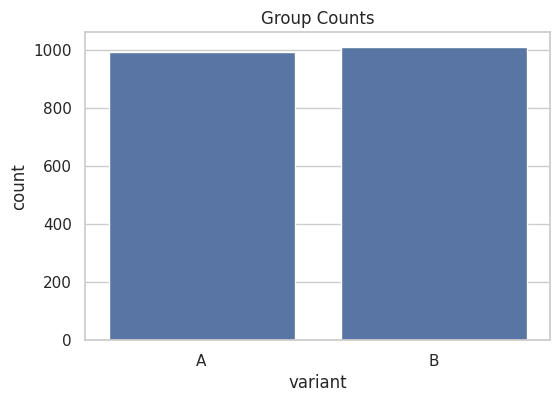

In [14]:
display(df.describe(include="all"))

plt.figure(figsize = (6,4))
sns.countplot(data = df, x = variant_col)
plt.title("Group Counts")
plt.show()

In [26]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove IDs
exclude_keywords = [
    "id",
    "user_id",
    "timestamp",
    "date",
    "time",
    "ts",
    "session_id",
    "uuid",
    "ip",
    "country_code",
    "zipcode",
    "postal",
    "risk",
    "fraud",
    "cheat",
    "bot",
    "quality_score",
    "debug",
    "log",
    "error",
    "random_seed"
]

metrics = []

for col in numeric_cols:
    if not any(k in col.lower() for k in exclude_keywords):
        metrics.append(col)

print("Metrics Found:")
print(metrics)

Metrics Found:
['age', 'grade_level', 'prior_platform_days', 'prior_sessions_30d', 'baseline_math_score', 'baseline_reading_score', 'self_efficacy_score', 'attention_score', 'study_goal_mins_week', 'session_count_14d', 'total_minutes_14d', 'avg_session_minutes', 'recommendations_served', 'recommendations_clicked', 'recommendations_completed', 'recommendation_ctr', 'recommendation_completion_rate', 'recommendation_relevance_survey_1_5', 'learning_speed_survey_1_5', 'ux_satisfaction_1_5', 'trust_ai_1_5', 'nps_score', 'module_completion_rate', 'post_quiz_score', 'score_gain_pct', 'retained_7d', 'retained_30d', 'refund_requested', 'fairness_flag', 'latency_ms_avg', 'app_crash_count', 'anomaly_flag']


In [27]:
def ab_test_continuous(df, metric, group_col):

    groups = df[group_col].unique()

    if len(groups) != 2:
        return None

    g1 = df[df[group_col] == groups[0]][metric].dropna()
    g2 = df[df[group_col] == groups[1]][metric].dropna()

    # normality sample
    s1 = g1.sample(min(len(g1), 500), random_state=42)
    s2 = g2.sample(min(len(g2), 500), random_state=42)

    p_norm1 = shapiro(s1)[1]
    p_norm2 = shapiro(s2)[1]

    p_var = levene(g1, g2)[1]

    if p_norm1 > 0.05 and p_norm2 > 0.05:
        stat, p = ttest_ind(g1, g2, equal_var=(p_var > 0.05))
        test_used = "t-test"
    else:
        stat, p = mannwhitneyu(g1, g2)
        test_used = "mannwhitney"

    mean1 = g1.mean()
    mean2 = g2.mean()

    lift = ((mean2 - mean1) / mean1) * 100 if mean1 != 0 else np.nan

    return {
        "metric": metric,
        "group_A": groups[0],
        "group_B": groups[1],
        "mean_A": mean1,
        "mean_B": mean2,
        "lift_%": lift,
        "test": test_used,
        "p_value": p
    }

In [28]:
results = []

for metric in metrics:
    try:
        r = ab_test_continuous(df, metric, variant_col)
        if r:
            results.append(r)
    except:
        pass

results_df = pd.DataFrame(results)

display(results_df.sort_values("p_value"))

,metric,group_A,group_B,mean_A,mean_B,lift_%,test,p_value
13,recommendations_clicked,A,B,4.676085,14.358771,207.068237,mannwhitney,0.000000e+00
15,recommendation_ctr,A,B,0.309919,0.514823,66.115063,t-test,9.368191e-305
14,recommendations_completed,A,B,3.345106,12.223984,265.428908,mannwhitney,3.899310e-303
12,recommendations_served,A,B,14.922301,27.892963,86.921333,mannwhitney,2.448568e-301
16,recommendation_completion_rate,A,B,0.226253,0.441308,95.050532,mannwhitney,4.063331e-208
22,module_completion_rate,A,B,0.581482,0.795869,36.869019,mannwhitney,8.004770e-160
17,recommendation_relevance_survey_1_5,A,B,3.073663,4.194252,36.457763,mannwhitney,2.436317e-149
24,score_gain_pct,A,B,6.591493,15.636700,137.225446,t-test,1.306855e-133
18,learning_speed_survey_1_5,A,B,3.103935,4.045590,30.337431,mannwhitney,6.919493e-116
9,session_count_14d,A,B,7.695257,11.099108,44.233098,mannwhitney,5.417615e-110


In [29]:
reject, p_adj, _, _ = multipletests(
    results_df["p_value"],
    method="fdr_bh"
)

results_df["adjusted_p"] = p_adj
results_df["significant"] = reject

display(results_df.sort_values("adjusted_p"))


,metric,group_A,group_B,mean_A,mean_B,lift_%,test,p_value,adjusted_p,significant
13,recommendations_clicked,A,B,4.676085,14.358771,207.068237,mannwhitney,0.000000e+00,0.000000e+00,True
15,recommendation_ctr,A,B,0.309919,0.514823,66.115063,t-test,9.368191e-305,1.498911e-303,True
14,recommendations_completed,A,B,3.345106,12.223984,265.428908,mannwhitney,3.899310e-303,4.159264e-302,True
12,recommendations_served,A,B,14.922301,27.892963,86.921333,mannwhitney,2.448568e-301,1.958854e-300,True
16,recommendation_completion_rate,A,B,0.226253,0.441308,95.050532,mannwhitney,4.063331e-208,2.600532e-207,True
22,module_completion_rate,A,B,0.581482,0.795869,36.869019,mannwhitney,8.004770e-160,4.269211e-159,True
17,recommendation_relevance_survey_1_5,A,B,3.073663,4.194252,36.457763,mannwhitney,2.436317e-149,1.113745e-148,True
24,score_gain_pct,A,B,6.591493,15.636700,137.225446,t-test,1.306855e-133,5.227421e-133,True
18,learning_speed_survey_1_5,A,B,3.103935,4.045590,30.337431,mannwhitney,6.919493e-116,2.460264e-115,True
9,session_count_14d,A,B,7.695257,11.099108,44.233098,mannwhitney,5.417615e-110,1.733637e-109,True


In [30]:
binary_cols = []

for col in metrics:
    uniq = df[col].dropna().unique()
    if set(uniq).issubset({0,1}):
        binary_cols.append(col)

print("Binary Metrics:", binary_cols)


binary_results = []

groups = df[variant_col].unique()

for metric in binary_cols:

    success = np.array([
        df[df[variant_col]==groups[0]][metric].sum(),
        df[df[variant_col]==groups[1]][metric].sum()
    ])

    nobs = np.array([
        len(df[df[variant_col]==groups[0]]),
        len(df[df[variant_col]==groups[1]])
    ])

    stat, p = proportions_ztest(success, nobs)

    rate1 = success[0]/nobs[0]
    rate2 = success[1]/nobs[1]

    lift = ((rate2-rate1)/rate1)*100 if rate1 != 0 else np.nan

    binary_results.append({
        "metric": metric,
        "rate_A": rate1,
        "rate_B": rate2,
        "lift_%": lift,
        "p_value": p
    })

binary_df = pd.DataFrame(binary_results)

display(binary_df.sort_values("p_value"))


Binary Metrics: ['retained_7d', 'retained_30d', 'refund_requested', 'fairness_flag', 'anomaly_flag']


,metric,rate_A,rate_B,lift_%,p_value
1,retained_30d,0.384460,0.602577,56.733233,1.761744e-22
0,retained_7d,0.633703,0.783944,23.708439,1.366154e-13
2,refund_requested,0.024218,0.013875,-42.707301,9.027832e-02
4,anomaly_flag,0.009082,0.016848,85.519216,1.252519e-01
3,fairness_flag,0.026236,0.029732,13.326218,6.355905e-01


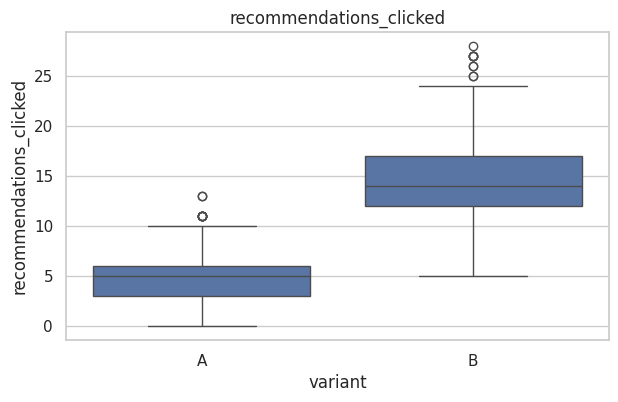

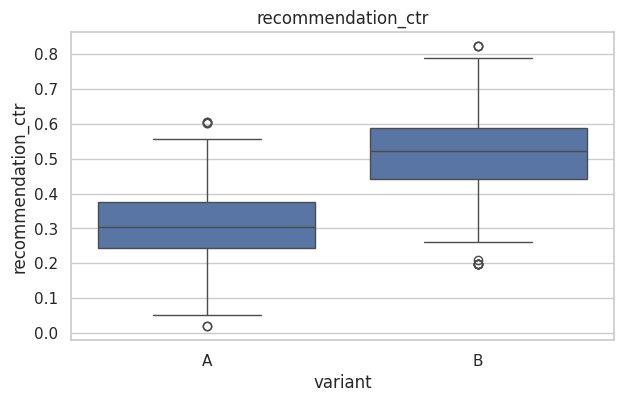

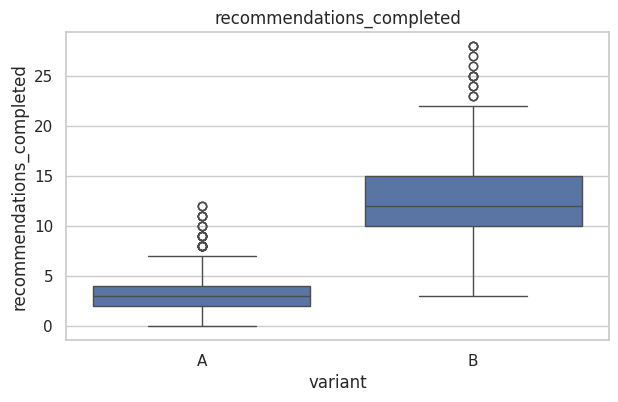

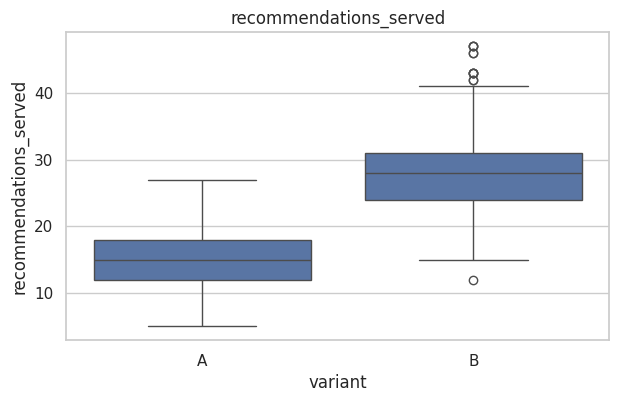

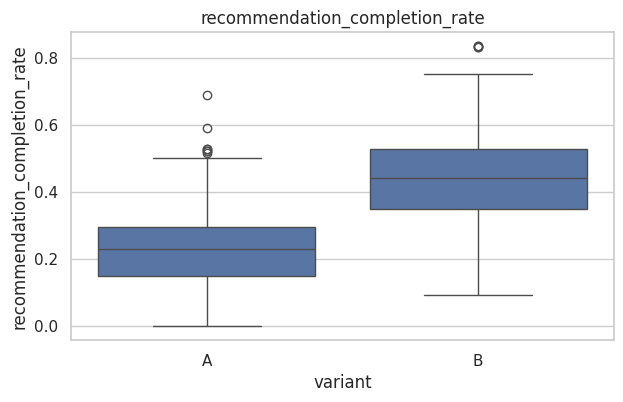

In [31]:
top_metrics = results_df.sort_values("adjusted_p").head(5)["metric"]

for metric in top_metrics:

    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x=variant_col, y=metric)
    plt.title(metric)
    plt.show()

In [32]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:

    if col == variant_col:
        continue

    if df[col].nunique() <= 6:

        print("\nSEGMENT:", col)

        table = pd.crosstab(df[col], df[variant_col])
        display(table)



SEGMENT: experiment_id


variant,A,B
experiment_id,,
EXP2026LP01,991,1009



SEGMENT: region


variant,A,B
region,,
East,209,244
North,231,238
South,273,266
West,278,261



SEGMENT: device_type


...

variant,A,B
parent_education,,
Bachelors,323,305
HighSchool,325,330
Masters,343,374



SEGMENT: income_band


variant,A,B
income_band,,
High,194,180
Low,307,283
Mid,490,546



SEGMENT: learning_style


variant,A,B
learning_style,,
Adaptive,191,203
Kinesthetic,179,211
Mixed,227,226
Reading,212,193
Visual,182,176


In [37]:
exclude_targets = [
    "age",
    "gender",
    "country",
    "device_type",
    "variant"
]

# Keep only true business KPI metrics
candidate_metrics = results_df[
    ~results_df["metric"].str.lower().isin(exclude_targets)
].copy()

# Pick best metric with lowest adjusted p-value
best_metric = candidate_metrics.sort_values(
    "adjusted_p"
).iloc[0]["metric"]

print("Selected Best KPI:", best_metric)


Selected Best KPI: recommendations_clicked


In [43]:
control_vars = {
    "grade_level":           "numeric",
    "baseline_math_score":   "numeric",
    "baseline_reading_score":"numeric",
    "prior_sessions_30d":    "numeric",
    "prior_platform_days":   "numeric",
    "age":                   "numeric",
    "region":                "categorical",   # was 'country' — wrong column name
    "device_type":           "categorical",
    "network_quality":       "categorical",
    "income_band":           "categorical",
    "learning_style":        "categorical",
}

formula = f'Q("{best_metric}") ~ C({variant_col})'

for col, kind in control_vars.items():
    if col in df.columns:
        if kind == "categorical":
            formula += f' + C({col})'
        else:
            formula += f' + Q("{col}")'
    else:
        print(f"WARNING: '{col}' not found in df — skipped")

print("Regression Formula:")
print(formula)

Regression Formula:
Q("recommendations_clicked") ~ C(variant) + Q("grade_level") + Q("baseline_math_score") + Q("baseline_reading_score") + Q("prior_sessions_30d") + Q("prior_platform_days") + Q("age") + C(region) + C(device_type) + C(network_quality) + C(income_band) + C(learning_style)


In [44]:
model = smf.ols(formula, data=df).fit()

print(model.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Q("recommendations_clicked")   R-squared:                       0.697
Model:                                      OLS   Adj. R-squared:                  0.693
Method:                           Least Squares   F-statistic:                     227.1
Date:                          Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                                  17:06:17   Log-Likelihood:                -5171.6
No. Observations:                          2000   AIC:                         1.039e+04
Df Residuals:                              1979   BIC:                         1.050e+04
Df Model:                                    20                                         
Covariance Type:                      nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------

In [45]:
summary = results_df.sort_values("adjusted_p")

winners = summary[
    (summary["significant"] == True) &
    (summary["lift_%"] > 0)
]

print("Winning Metrics:")
display(winners)



Winning Metrics:


,metric,group_A,group_B,mean_A,mean_B,lift_%,test,p_value,adjusted_p,significant
13,recommendations_clicked,A,B,4.676085,14.358771,207.068237,mannwhitney,0.000000e+00,0.000000e+00,True
15,recommendation_ctr,A,B,0.309919,0.514823,66.115063,t-test,9.368191e-305,1.498911e-303,True
14,recommendations_completed,A,B,3.345106,12.223984,265.428908,mannwhitney,3.899310e-303,4.159264e-302,True
12,recommendations_served,A,B,14.922301,27.892963,86.921333,mannwhitney,2.448568e-301,1.958854e-300,True
16,recommendation_completion_rate,A,B,0.226253,0.441308,95.050532,mannwhitney,4.063331e-208,2.600532e-207,True
22,module_completion_rate,A,B,0.581482,0.795869,36.869019,mannwhitney,8.004770e-160,4.269211e-159,True
17,recommendation_relevance_survey_1_5,A,B,3.073663,4.194252,36.457763,mannwhitney,2.436317e-149,1.113745e-148,True
24,score_gain_pct,A,B,6.591493,15.636700,137.225446,t-test,1.306855e-133,5.227421e-133,True
18,learning_speed_survey_1_5,A,B,3.103935,4.045590,30.337431,mannwhitney,6.919493e-116,2.460264e-115,True
9,session_count_14d,A,B,7.695257,11.099108,44.233098,mannwhitney,5.417615e-110,1.733637e-109,True


In [46]:
print("\n========== FINAL DECISION ==========")

if len(winners) > 0:
    print("Variant B has positive statistically significant impact.")
    print("Recommend staged rollout.")
else:
    print("No clear winner detected.")
    print("Need more data or stronger treatment.")




========== FINAL DECISION ==========
Variant B has positive statistically significant impact.
Recommend staged rollout.


In [47]:
results_df.to_excel("clean_ab_test_results.xlsx", index=False)
files.download("clean_ab_test_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>